# Airbnb Pricing Analysis — San Francisco
### *What makes a listing expensive? Location or the property itself?*
> Is Airbnb Pricing Driven by Property Value or Neighborhood Prestige?

---

**Dataset:** https://insideairbnb.com/san-francisco/ — San Francisco, CA  
**Tools:** Python · Pandas · Seaborn · Matplotlib · Scikit-learn · SciPy

---
## The Question

Airbnb has thousands of listings in SF. Some charge \\$80/night, others charge \\$800/night.

**What's actually driving that difference?**
- Is it *where* the property is (the neighbourhood)?
- Or *what* the property offers (size, amenities, quality)?
 
 ---
## Business Problem

This matters to three stakeholders:
- **New hosts** — should they invest in amenities, or just pick the right neighbourhood?
- **Guests** — are they overpaying for a postcode, or getting fair value?
- **Airbnb (platform)** — where do dynamic pricing nudges have the most impact?

---

## What We'll Find Out

1. How are prices distributed across SF listings?
2. Which neighbourhoods are the most expensive?
3. Does a bigger property always mean a higher price?
4. Do guest reviews have any relationship with price?
5. Which single factor matters the most?


## Section 1 — Environment Setup

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# ── Airbnb brand palette ──────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
})
ACCENT = "#FF5A5F"   # Airbnb red
BLUE   = "#3B82F6"
GREEN  = "#10B981"
PURPLE = "#8B5CF6"
ORANGE = "#F59E0B"
PALETTE = [ACCENT, BLUE, GREEN, PURPLE, ORANGE]

print(" Libraries loaded.")


 Libraries loaded.


## Section 2 — Data Loading

**Source:** Inside Airbnb provides quarterly snapshots of public Airbnb listing data for major cities.  
We use four files for Los Angeles. Update the paths below to match your local directory.


In [50]:
# ── Load raw files ────────────────────────────────────────
listings      = pd.read_csv("listings.csv")
neighbourhoods = pd.read_csv("neighbourhoods.csv")
reviews       = pd.read_csv("reviews.csv")
calendar      = pd.read_csv("calendar.csv.gz", compression="gzip")

print(f"listings:       {listings.shape[0]:,} rows × {listings.shape[1]} cols")
print(f"neighbourhoods: {neighbourhoods.shape[0]:,} rows × {neighbourhoods.shape[1]} cols")
print(f"reviews:        {reviews.shape[0]:,} rows × {reviews.shape[1]} cols")
print(f"calendar:       {calendar.shape[0]:,} rows × {calendar.shape[1]} cols")


listings:       7,780 rows × 79 cols
neighbourhoods: 37 rows × 2 cols
reviews:        410,017 rows × 6 cols
calendar:       2,839,700 rows × 7 cols


In [51]:
# Quick schema scan of the main table
listings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7780 entries, 0 to 7779
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7780 non-null   int64  
 1   listing_url                                   7780 non-null   object 
 2   scrape_id                                     7780 non-null   int64  
 3   last_scraped                                  7780 non-null   object 
 4   source                                        7780 non-null   object 
 5   name                                          7780 non-null   object 
 6   description                                   7688 non-null   object 
 7   neighborhood_overview                         4683 non-null   object 
 8   picture_url                                   7780 non-null   object 
 9   host_id                                       7780 non-null   i

## Section 3 — Data Cleaning & Feature Engineering

### 3.1 Column Selection

Trim the raw 70+ column dataset down to the features relevant to our pricing question, grouped by theme.


In [52]:
# ── Column groups ─────────────────────────────────────────
COLS_LOCATION = [
    "neighbourhood_cleansed", "latitude", "longitude",
    "review_scores_location",       # guest-facing location rating
]
COLS_PROPERTY = [
    "property_type", "room_type",
    "accommodates", "bedrooms", "bathrooms_text", "beds", "amenities",
]
COLS_REVIEW = [
    "number_of_reviews", "review_scores_rating",
    "review_scores_cleanliness", "review_scores_communication",
    "review_scores_value",
]
COLS_HOST = [
    "host_is_superhost", "host_listings_count", "host_identity_verified",
]
COLS_TARGET = ["price"]

all_cols = COLS_LOCATION + COLS_PROPERTY + COLS_REVIEW + COLS_HOST + COLS_TARGET
all_cols = [c for c in all_cols if c in listings.columns]

df = listings[all_cols].copy()
print(f"Selected {len(df.columns)} columns from {listings.shape[1]} total.")
df.head(3)


Selected 20 columns from 79 total.


,neighbourhood_cleansed,latitude,longitude,review_scores_location,property_type,room_type,accommodates,bedrooms,bathrooms_text,beds,amenities,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_value,host_is_superhost,host_listings_count,host_identity_verified,price
0,Western Addition,37.77028,-122.43317,4.98,Entire serviced apartment,Entire home/apt,3,1.0,1 bath,2.0,"[""Clothing storage: closet and dresser"", ""Esse...",496,4.89,4.93,4.89,4.78,t,1.0,t,$157.00
1,Bernal Heights,37.74474,-122.42089,4.77,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,"[""Carbon monoxide alarm"", ""Shampoo"", ""Hair dry...",105,4.87,4.87,4.85,4.68,f,2.0,t,$250.00
2,Outer Mission,37.73077,-122.44827,4.59,Private room in home,Private room,1,1.0,2 shared baths,1.0,"[""Dryer"", ""Essentials"", ""Hangers"", ""Backyard"",...",90,4.77,4.30,4.94,4.66,t,3.0,t,$67.00


### 3.2 Missing Values & Duplicates

In [53]:
# ── Listings: nulls & duplicates ─────────────────────────
print(f"Duplicate rows: {listings.duplicated().sum()}")
print()
print("Null counts (selected columns):")
print(df.isnull().sum().sort_values(ascending=False).to_string())


Duplicate rows: 0

Null counts (selected columns):
price                          1985
beds                           1958
review_scores_location         1871
review_scores_value            1871
review_scores_rating           1870
review_scores_communication    1870
review_scores_cleanliness      1870
bedrooms                        489
host_is_superhost               137
bathrooms_text                   51
host_identity_verified            1
host_listings_count               1
neighbourhood_cleansed            0
number_of_reviews                 0
latitude                          0
accommodates                      0
room_type                         0
property_type                     0
longitude                         0
amenities                         0


In [54]:
# ── Calendar: nulls & duplicates ─────────────────────────
print(f"Duplicate rows: {calendar.duplicated().sum()}")
print()
print("Null counts:")
print(calendar.isnull().sum().sort_values(ascending=False).to_string())


Duplicate rows: 0

Null counts:
price             2839700
adjusted_price    2839700
listing_id              0
date                    0
available               0
minimum_nights          0
maximum_nights          0


In [55]:
# Drop rows where price is missing in calendar
calendar = calendar.dropna(subset=["price", "adjusted_price"])
print(f"Calendar after dropping price NAs: {len(calendar):,} rows")


Calendar after dropping price NAs: 0 rows


### 3.3 Feature Engineering

We create derived features to make the data model-ready:
- Parse `price` from `"$1,200.00"` string → float
- Extract numeric bathrooms from text like `"1.5 baths"`
- Encode boolean host flags
- Count amenities as a numeric signal


In [56]:
# ── Price: strip $ and commas, clip outliers ─────────────
df["price"] = (
    df["price"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
    .replace("", np.nan)
    .astype(float)
)

# Remove rows with no price
df = df.dropna(subset=["price"])

# Remove extreme outliers (bottom 1% and top 1%)
# These are usually data errors or ultra-luxury properties that skew everything
q_low, q_high = df["price"].quantile(0.01), df["price"].quantile(0.99)
df = df[(df["price"] >= q_low) & (df["price"] <= q_high)]

df["log_price"] = np.log1p(df["price"])

print(f"Listings after cleaning: {len(df):,}")
print(f"Price range: ${df['price'].min():.0f} – ${df['price'].max():.0f} per night")
print(f"Median price: ${df['price'].median():.0f} per night")

# ── Bathrooms: parse "1.5 baths" to 1.5 ──────────────────
if "bathrooms_text" in df.columns:
    df["bathrooms"] = (
        df["bathrooms_text"].astype(str)
        .str.extract(r"([\d.]+)")[0]
        .astype(float)
    )

# ── Host flags: t/f to 1/0 ────────────────────────────────
for col in ["host_is_superhost", "host_identity_verified"]:
    if col in df.columns:
        df[col] = df[col].map({"t": 1, "f": 0, True: 1, False: 0}).fillna(0)

# ── Amenity count ─────────────────────────────────────────
if "amenities" in df.columns:
    df["amenity_count"] = (
        df["amenities"].astype(str)
        .apply(lambda x: len([a for a in x.split(",") if a.strip()]))
    )

# ── Focus: keep top 30 neighbourhoods by listing count ────
top_neigh = df["neighbourhood_cleansed"].value_counts().head(30).index
df_top = df[df["neighbourhood_cleansed"].isin(top_neigh)].copy()

print(f"Working dataset: {len(df_top):,} listings across {df_top['neighbourhood_cleansed'].nunique()} neighbourhoods")


Listings after cleaning: 5,682
Price range: $42 – $1614 per night
Median price: $170 per night
Working dataset: 5,596 listings across 30 neighbourhoods


## Section 4 — Exploratory Data Analysis

### Question 1: How are prices spread out?

- Before comparing anything, we need to understand our main variable: **price**.
- A right-skewed price distribution is typical in rental markets — a log transform
normalizes it for regression analysis.
---

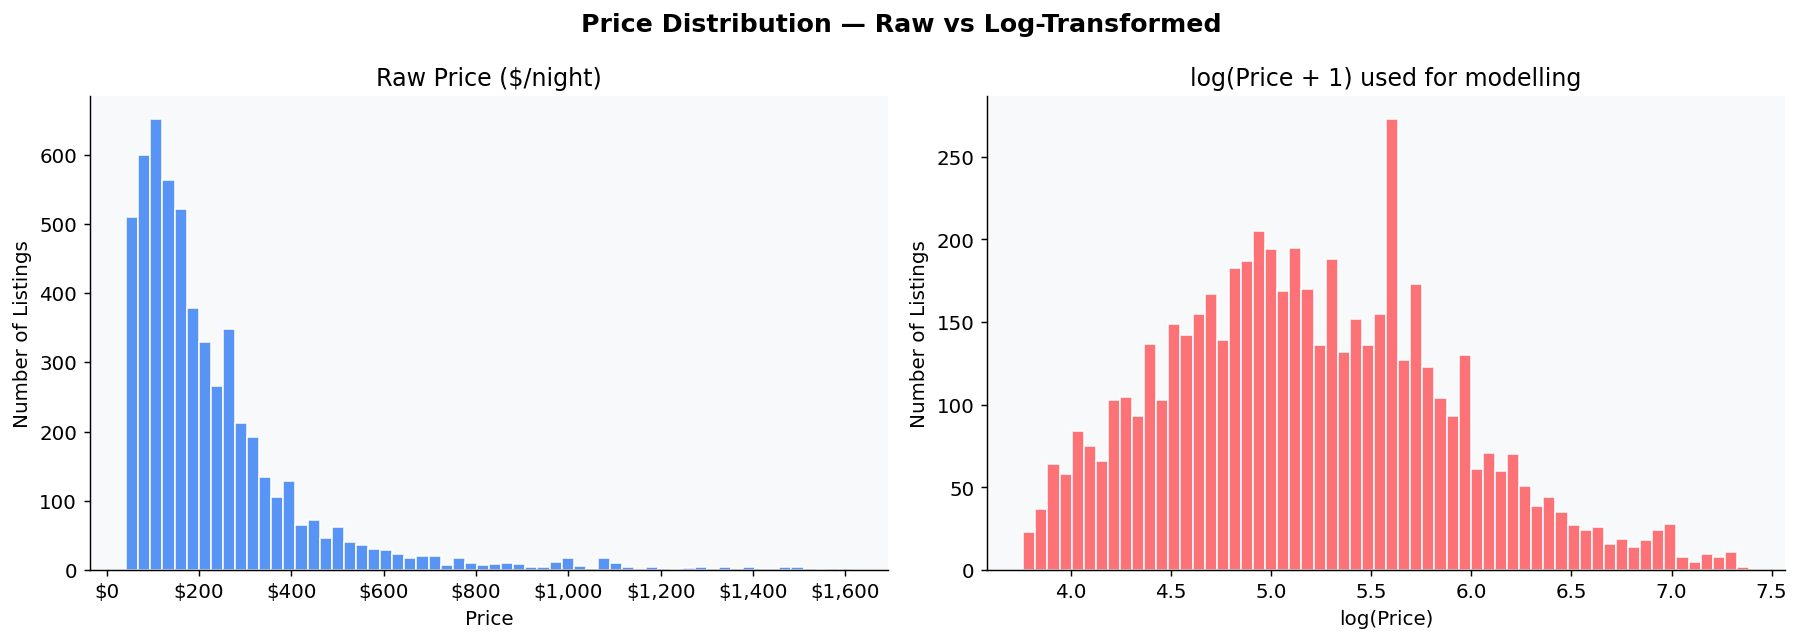

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Price Distribution — Raw vs Log-Transformed", fontsize=14, fontweight="bold")

axes[0].hist(df_top["price"], bins=60, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].set_title("Raw Price ($/night)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Listings")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1].hist(df_top["log_price"], bins=60, color=ACCENT, edgecolor="white", alpha=0.85)
axes[1].set_title("log(Price + 1) used for modelling")
axes[1].set_xlabel("log(Price)")
axes[1].set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()


In [58]:
# summary box
price_stats = df_top["price"].describe()
summary_text = (
    f"  Price Summary\n"
    f"  {'─'*28}\n"
    f"  Listings analysed : {len(df_top):,}\n"
    f"  Cheapest (1%)     : ${q_low:.0f}/night\n"
    f"  Most common range : ${price_stats['25%']:.0f} – ${price_stats['75%']:.0f}/night\n"
    f"  Median            : ${price_stats['50%']:.0f}/night\n"
    f"  Average           : ${price_stats['mean']:.0f}/night\n"
    f"  Most expensive    : ${price_stats['max']:.0f}/night\n"
)
print(summary_text)

  Price Summary
  ────────────────────────────
  Listings analysed : 5,596
  Cheapest (1%)     : $42/night
  Most common range : $106 – $283/night
  Median            : $170/night
  Average           : $232/night
  Most expensive    : $1614/night



**Q1 - Price Distribution Insight:**

- Most listings cluster in the \\$106–\\$283/night range, but a long tail of expensive listings pulls the average up. This is a classic pattern in pricing data — a few premium listings are much pricier than the majority.
  
- Raw price is heavily right-skewed — a handful of luxury listings inflate the mean.


- The log-transformed version approximates a normal distribution, making it suitable for correlation analysis and linear models.


### Question 2: Which neighbourhoods are most expensive?

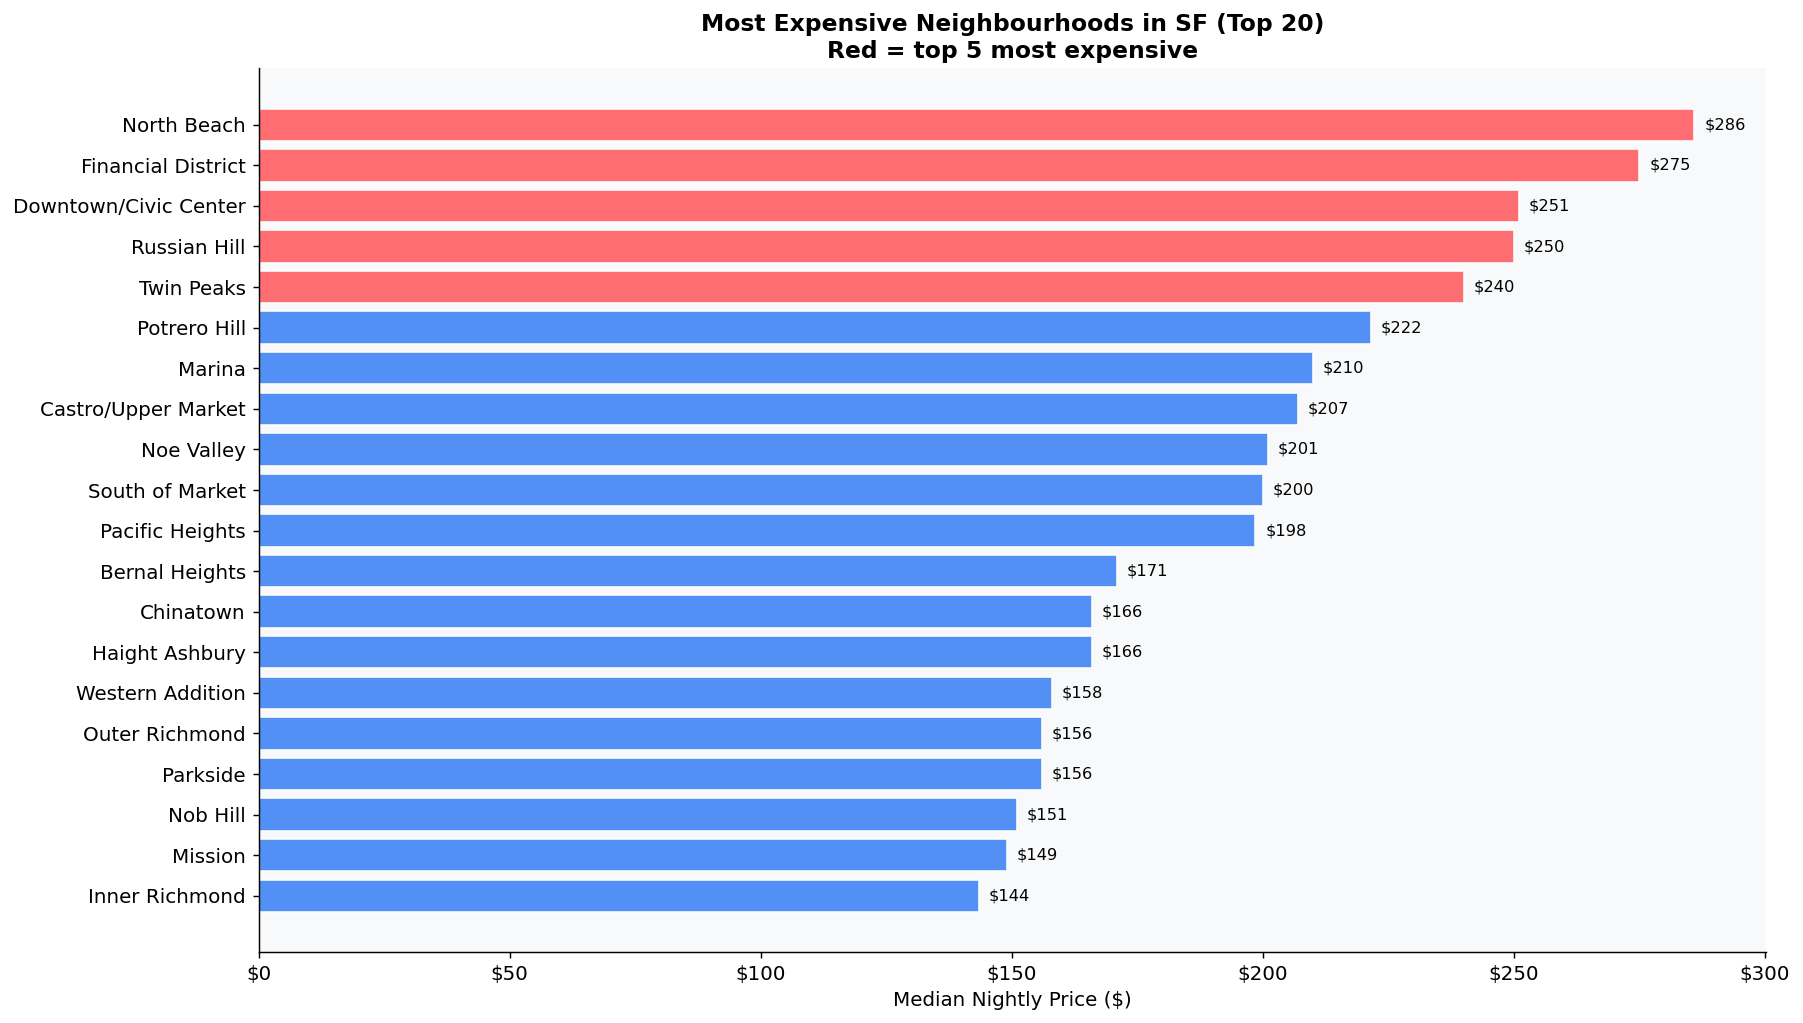

Top 5 most expensive neighbourhoods:
                        Median Price  Listings
neighbourhood_cleansed                        
North Beach                    286.0       166
Financial District             275.0       149
Downtown/Civic Center          251.0       733
Russian Hill                   250.0       136
Twin Peaks                     240.0        48


In [61]:
# Calculate median price per neighbourhood (median is better than average here — less affected by outliers)
neigh_stats = (
    df_top.groupby("neighbourhood_cleansed")["price"]
    .agg(median="median", mean="mean", count="count", std="std")
    .sort_values("median", ascending=False)
)

# Plot top 20
fig, ax = plt.subplots(figsize=(14, 8))
top20 = neigh_stats.head(20).reset_index()

colors = [ACCENT if i < 5 else BLUE for i in range(len(top20))]
bars = ax.barh(
    top20["neighbourhood_cleansed"][::-1],
    top20["median"][::-1],
    color=colors[::-1], edgecolor="white", alpha=0.88
)
ax.set_xlabel("Median Nightly Price ($)")
ax.set_title("Most Expensive Neighbourhoods in SF (Top 20)\nRed = top 5 most expensive",fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Add price labels on bars
for bar, val in zip(bars, top20["median"][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Top 5 most expensive neighbourhoods:")
print(neigh_stats.head(5)[["median", "count"]].rename(columns={"median": "Median Price", "count": "Listings"}).to_string())


**Q2 - Most expensive neighbourhoods Insight:** 

There's a wide spread in median prices across neighbourhoods — 
but this alone doesn't tell us if it's driven by *location prestige* or the fact that 
expensive areas happen to have bigger, better-equipped properties.


### Question 3: Does room type affect price?

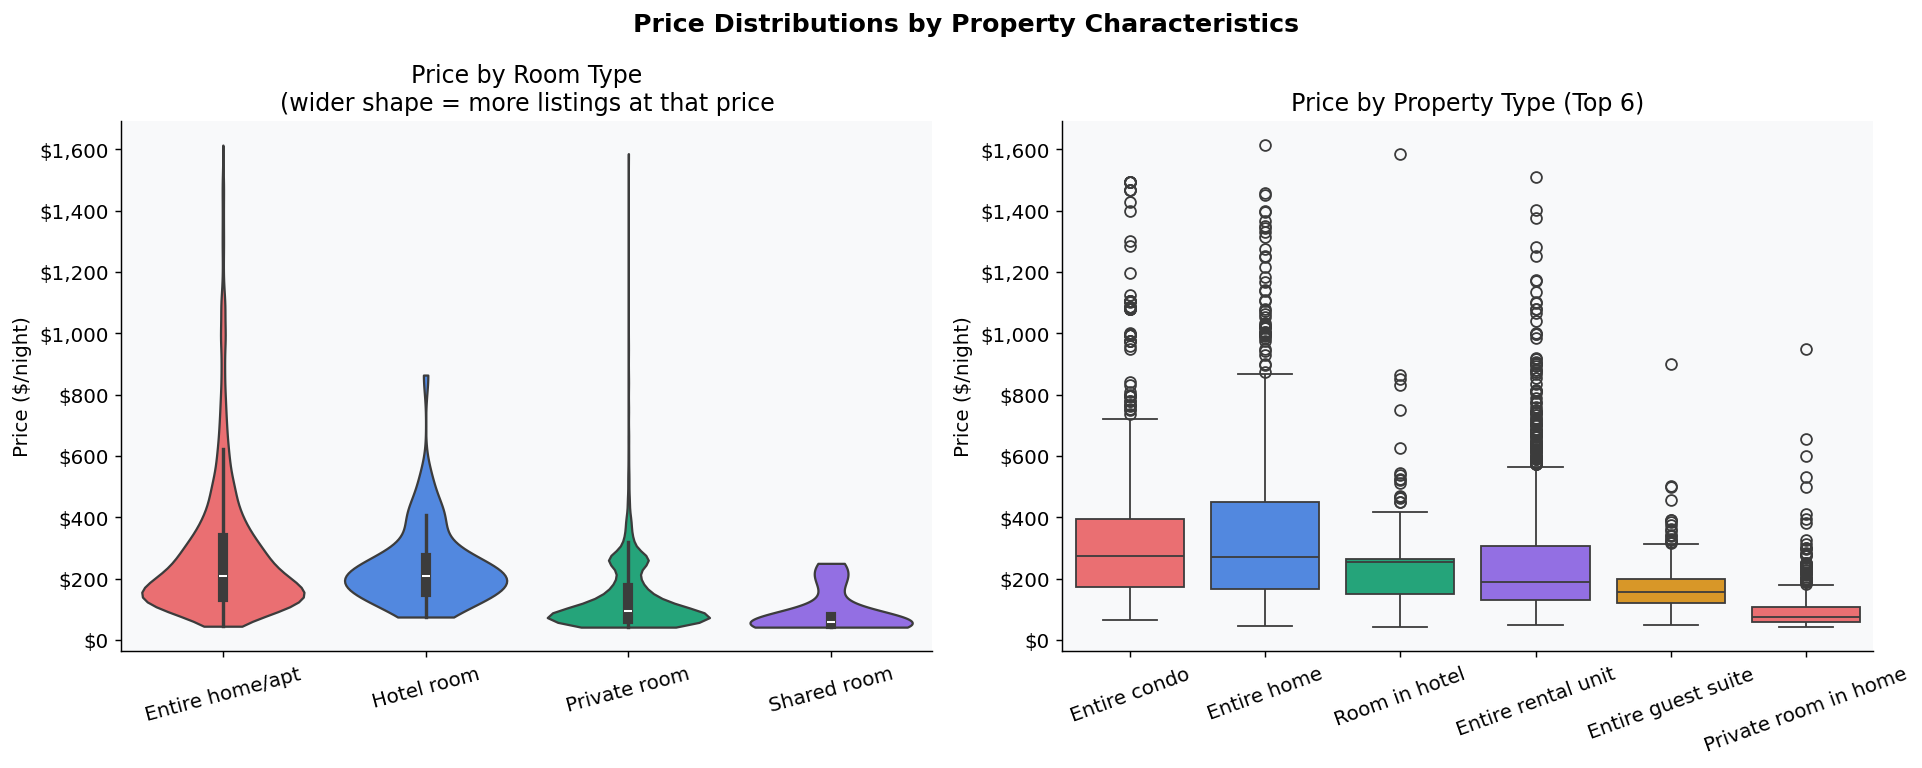

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Price Distributions by Property Characteristics", fontsize=14, fontweight="bold")

# Room type violin
room_order = df_top.groupby("room_type")["price"].median().sort_values(ascending=False).index
sns.violinplot(data=df_top, x="room_type", y="price", order=room_order,
               palette=PALETTE, ax=axes[0], cut=0, inner="box")

axes[0].set_title("Price by Room Type\n(wider shape = more listings at that price")
axes[0].set_xlabel("")
axes[0].set_ylabel("Price ($/night)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis="x", rotation=15)


# Property type top 6
top_props = df_top["property_type"].value_counts().head(6).index
df_props = df_top[df_top["property_type"].isin(top_props)]
prop_order = df_props.groupby("property_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df_props, x="property_type", y="price", order=prop_order,
            palette=PALETTE, ax=axes[1])

axes[1].set_title("Price by Property Type (Top 6)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price ($/night)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Q3 - How Property Type Affects Price Insight:** 

Entire homes/apartments cost significantly more than private or shared rooms —
confirming that room type is a fundamental pricing variable that must be controlled for
before comparing neighbourhoods.


## Section 5 — Feature Analysis: What Actually Drives the Price?

### Question 4: Does a bigger property mean a higher price?


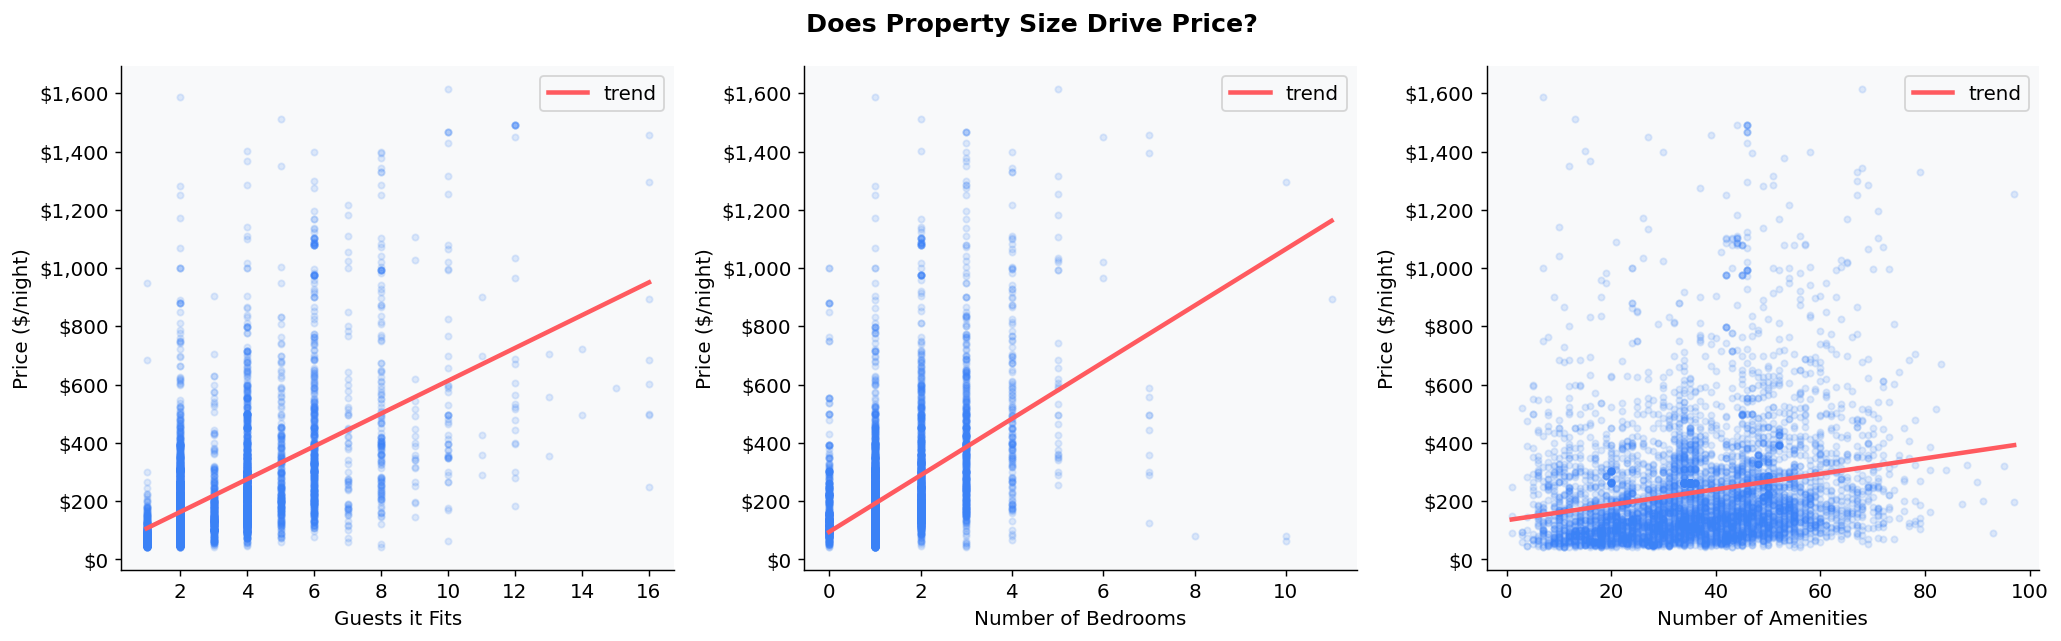

In [63]:
# Look at how capacity relates to price
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Does Property Size Drive Price?", fontsize=14, fontweight="bold")

for ax, col, label in zip(axes,
                           ["accommodates", "bedrooms", "amenity_count"],
                           ["Guests it Fits", "Number of Bedrooms", "Number of Amenities"]):
    tmp = df_top[[col, "price"]].dropna()
    ax.scatter(tmp[col], tmp["price"], alpha=0.15, s=12, color=BLUE)
    # Add a simple trend line
    m, b = np.polyfit(tmp[col], tmp["price"], 1)
    x_line = np.linspace(tmp[col].min(), tmp[col].max(), 50)
    ax.plot(x_line, m * x_line + b, color=ACCENT, linewidth=2.5, label="trend")
    ax.set_xlabel(label)
    ax.set_ylabel("Price ($/night)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend()

plt.tight_layout()
plt.show()


**Insight:** All three show a clear upward trend — bigger properties with more amenities charge more. The relationship isn't perfect (there's a lot of scatter), but the direction is consistent.


### Question 5: Do guest ratings relate to price?

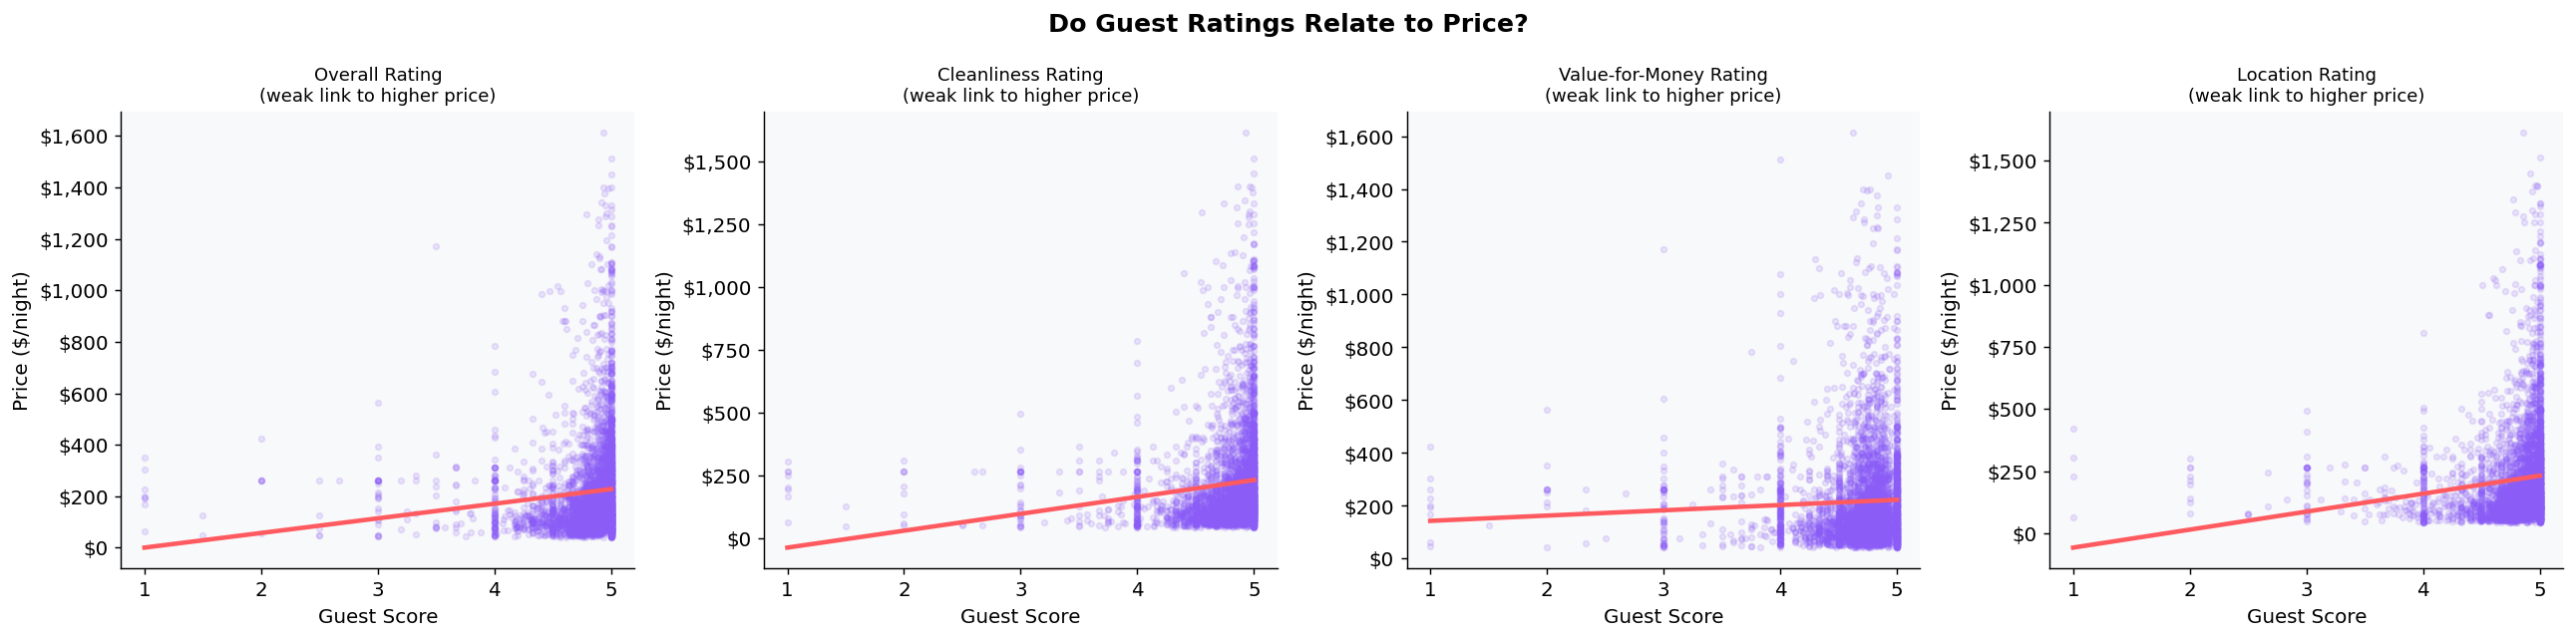

In [64]:
review_features = [
    ("review_scores_rating",      "Overall Rating"),
    ("review_scores_cleanliness", "Cleanliness Rating"),
    ("review_scores_value",       "Value-for-Money Rating"),
    ("review_scores_location",    "Location Rating"),
]
review_features = [(col, label) for col, label in review_features if col in df_top.columns]

fig, axes = plt.subplots(1, len(review_features), figsize=(5 * len(review_features), 5))
fig.suptitle("Do Guest Ratings Relate to Price?", fontsize=14, fontweight="bold")
if len(review_features) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, review_features):
    tmp = df_top[[col, "price"]].dropna()
    r, p = stats.pearsonr(tmp[col], tmp["price"])
    ax.scatter(tmp[col], tmp["price"], alpha=0.15, s=10, color=PURPLE)
    m, b = np.polyfit(tmp[col], tmp["price"], 1)
    xl = np.linspace(tmp[col].min(), tmp[col].max(), 50)
    ax.plot(xl, m * xl + b, color=ACCENT, linewidth=2.5)
    # Simple plain-English strength label
    strength = "strong" if abs(r) > 0.4 else ("moderate" if abs(r) > 0.2 else "weak")
    direction = "higher price" if r > 0 else "lower price"
    ax.set_title(f"{label}\n({strength} link to {direction})", fontsize=10)
    ax.set_xlabel(f"Guest Score")
    ax.set_ylabel("Price ($/night)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()


**Q5 - Guest ratings influence on price Insight:**

- Review scores have a surprisingly *weak* link to price. 
- High cleanliness scores have a modest positive link (cleaner properties charge slightly more)
- "Value for money" ratings actually trend *downward* — the most expensive listings often get lower value ratings from guests
- Location scores have almost no relationship with price

This tells us guests' opinions don't strongly determine what hosts charge.


### Question 6: Which single factor has the strongest link to price?


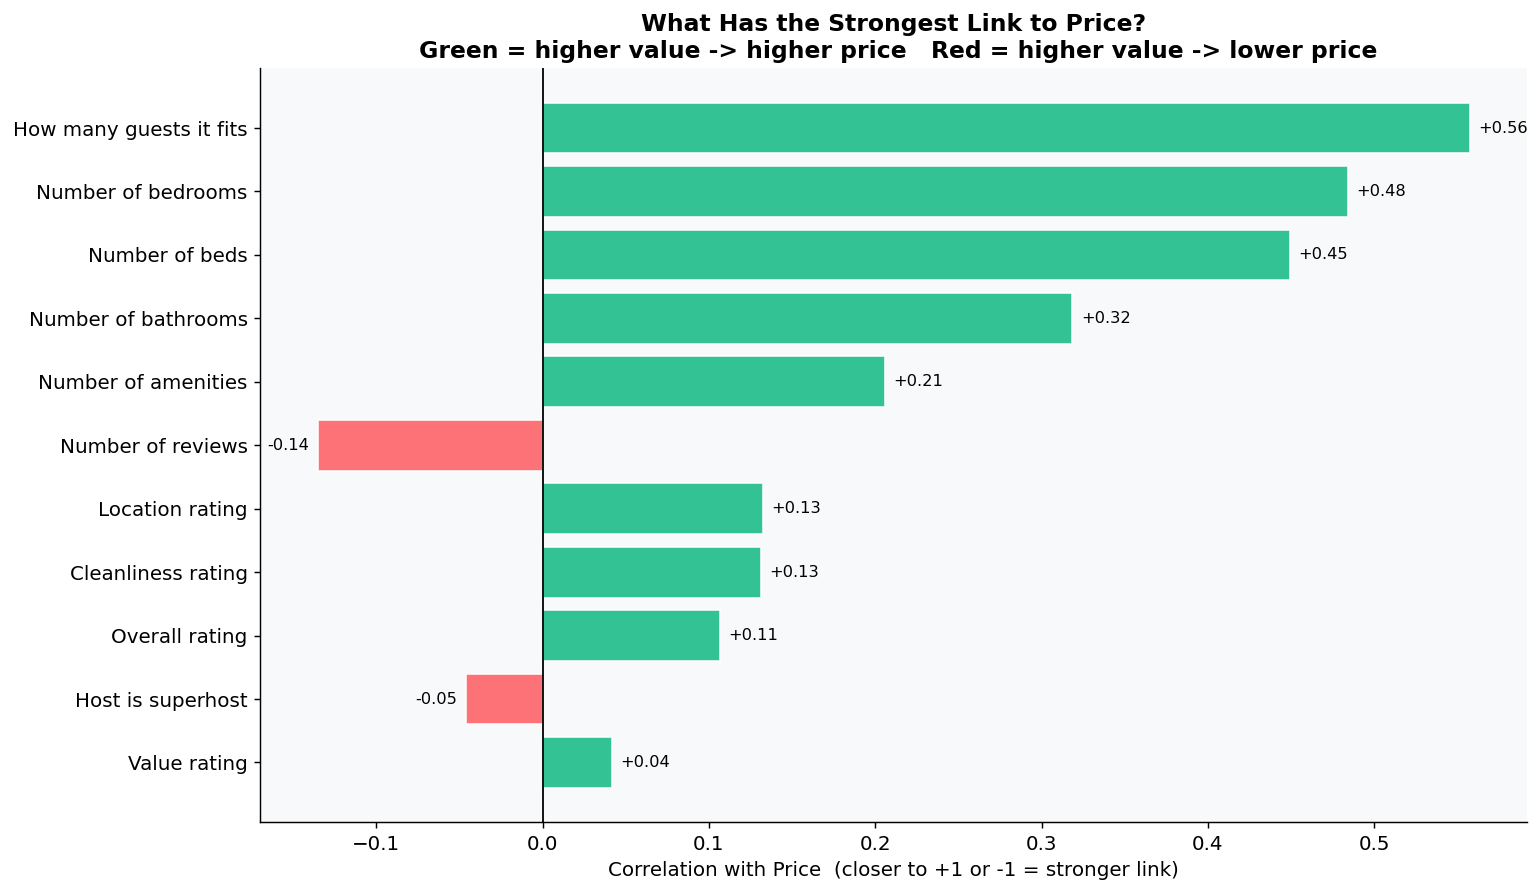


Ranking (strongest to weakest link to price):
  ★★★ Strong  How many guests it fits        ↑ more = pricier
  ★★★ Strong  Number of bedrooms             ↑ more = pricier
  ★★★ Strong  Number of beds                 ↑ more = pricier
  ★★  Moderate  Number of bathrooms            ↑ more = pricier
  ★★  Moderate  Number of amenities            ↑ more = pricier
  ★   Weak  Number of reviews              ↓ more = cheaper
  ★   Weak  Location rating                ↑ more = pricier
  ★   Weak  Cleanliness rating             ↑ more = pricier
  ★   Weak  Overall rating                 ↑ more = pricier
  ★   Weak  Host is superhost              ↓ more = cheaper
  ★   Weak  Value rating                   ↑ more = pricier


In [65]:
features_to_check = {
    "accommodates":              "How many guests it fits",
    "bedrooms":                  "Number of bedrooms",
    "bathrooms":                 "Number of bathrooms",
    "beds":                      "Number of beds",
    "amenity_count":             "Number of amenities",
    "review_scores_rating":      "Overall rating",
    "review_scores_cleanliness": "Cleanliness rating",
    "review_scores_value":       "Value rating",
    "review_scores_location":    "Location rating",
    "host_is_superhost":         "Host is superhost",
    "number_of_reviews":         "Number of reviews",
}
features_to_check = {k: v for k, v in features_to_check.items() if k in df_top.columns}

results = []
for col, label in features_to_check.items():
    tmp = df_top[[col, "price"]].dropna()
    if len(tmp) < 100:
        continue
    r, _ = stats.pearsonr(tmp[col], tmp["price"])
    results.append({"Feature": label, "Correlation": r, "col": col})

results_df = pd.DataFrame(results).sort_values("Correlation", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = [GREEN if r >= 0 else ACCENT for r in results_df["Correlation"]]
bars = ax.barh(results_df["Feature"][::-1], results_df["Correlation"][::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Correlation with Price  (closer to +1 or -1 = stronger link)")
ax.set_title("What Has the Strongest Link to Price?\n Green = higher value -> higher price   Red = higher value -> lower price",
             fontsize=13, fontweight="bold")

# Add value labels
for bar, val in zip(bars, results_df["Correlation"][::-1]):
    label_text = f"{val:+.2f}"
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            label_text, va="center", ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

print("\nRanking (strongest to weakest link to price):")
for _, row in results_df.iterrows():
    strength = "★★★ Strong" if abs(row["Correlation"]) > 0.4 else ("★★  Moderate" if abs(row["Correlation"]) > 0.2 else "★   Weak")
    direction = "↑ more = pricier" if row["Correlation"] > 0 else "↓ more = cheaper"
    print(f"  {strength}  {row['Feature']:<30} {direction}")


**Q6 - strongest to weakest link to price Insights:**

- Property size features (capacity, bedrooms, bathrooms) have the strongest positive links to price.
  
- The "value rating" has a negative link — guests who feel they're getting good value are often in cheaper listings.

## Neighbourhood Deep Dive

### Is it really the neighbourhood, or just that expensive areas have bigger homes?

1. For each neighbourhood, calculate the **median price**
2. Also calculate the **median property size** (accommodates)
3. If price perfectly followed size, all neighbourhoods would fall on a straight line
4. Neighbourhoods that sit *above* the line are charging extra for their location


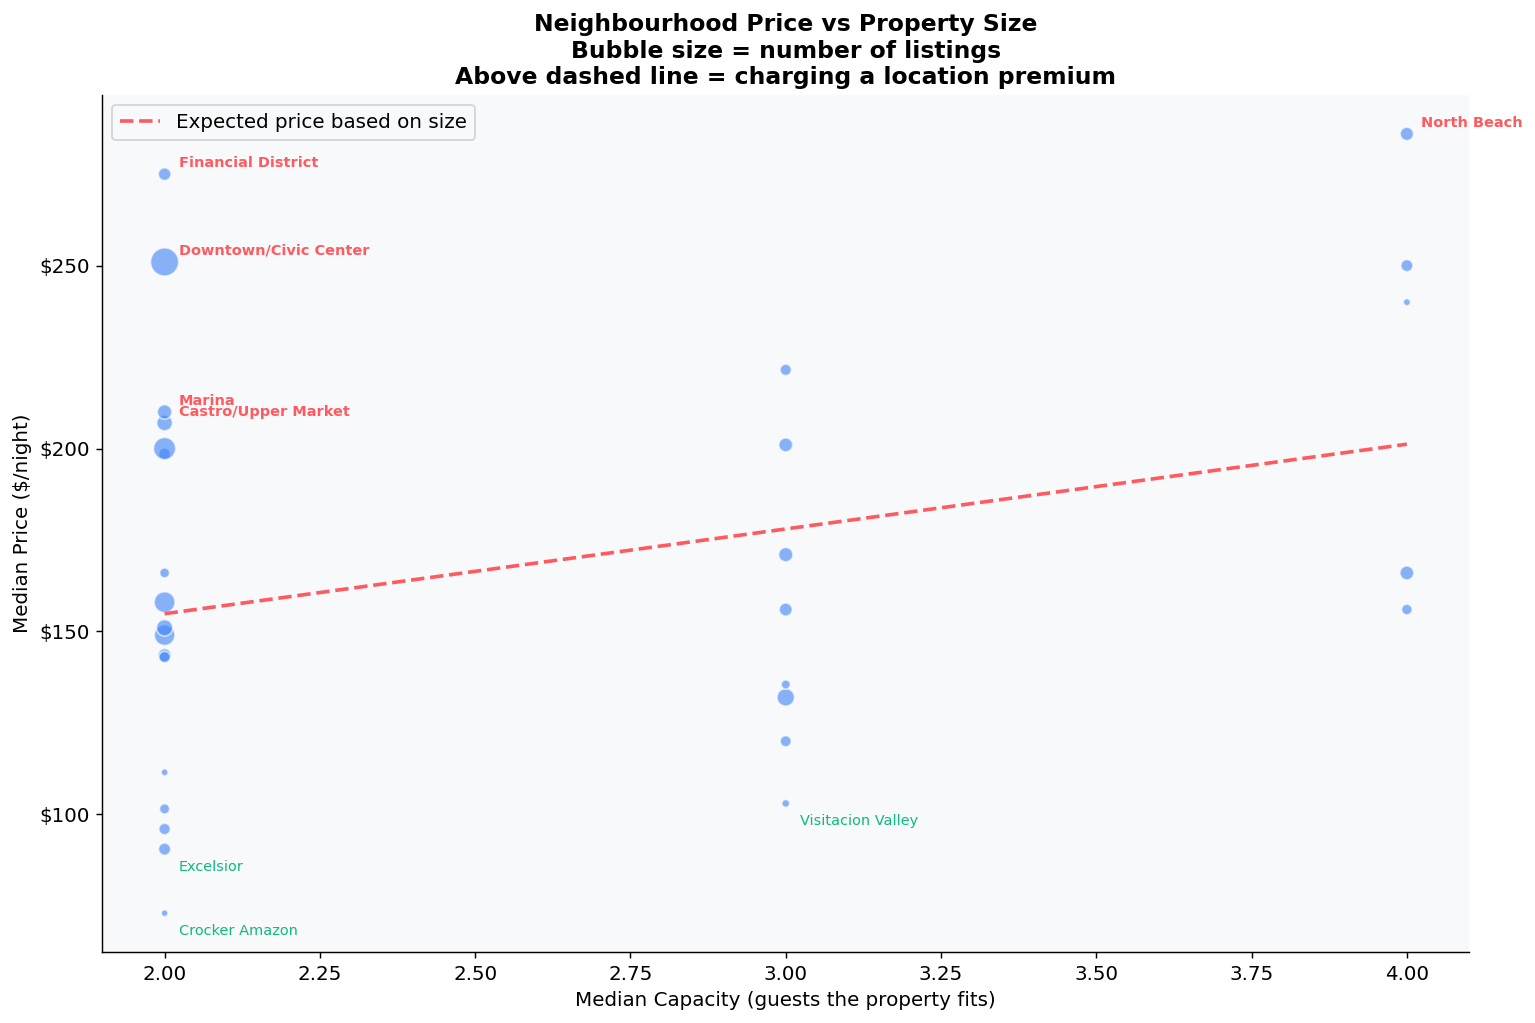

Neighbourhoods charging ABOVE what their size predicts (location premium):
        Neighbourhood  Actual Median $  Median Capacity  Premium Over Prediction $
   Financial District            275.0              2.0                 120.151163
Downtown/Civic Center            251.0              2.0                  96.151163
          North Beach            286.0              4.0                  84.813953
               Marina            210.0              2.0                  55.151163
  Castro/Upper Market            207.0              2.0                  52.151163

Neighbourhoods that are GOOD VALUE (below prediction):
    Neighbourhood  Actual Median $  Median Capacity  Gap to Prediction $
   Crocker Amazon             73.0              2.0           -81.848837
Visitacion Valley            103.0              3.0           -75.017442
        Excelsior             90.5              2.0           -64.348837


In [66]:
# Summarise each neighbourhood
neigh_summary = df_top.groupby("neighbourhood_cleansed").agg(
    median_price=("price", "median"),
    median_capacity=("accommodates", "median"),
    median_bedrooms=("bedrooms", "median"),
    listing_count=("price", "count"),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter: size vs price per neighbourhood
sc = ax.scatter(
    neigh_summary["median_capacity"],
    neigh_summary["median_price"],
    s=neigh_summary["listing_count"] / 3,   # bubble size = number of listings
    alpha=0.6, color=BLUE, edgecolors="white", linewidth=1
)

# Add trend line
m, b = np.polyfit(neigh_summary["median_capacity"], neigh_summary["median_price"], 1)
x_range = np.linspace(neigh_summary["median_capacity"].min(),
                      neigh_summary["median_capacity"].max(), 100)
ax.plot(x_range, m * x_range + b, color=ACCENT, linewidth=2,
        linestyle="--", label="Expected price based on size")

# Label neighbourhoods that sit far above or below the trend line
neigh_summary["predicted"] = m * neigh_summary["median_capacity"] + b
neigh_summary["gap"] = neigh_summary["median_price"] - neigh_summary["predicted"]

for _, row in neigh_summary.nlargest(5, "gap").iterrows():
    ax.annotate(row["neighbourhood_cleansed"],
                xy=(row["median_capacity"], row["median_price"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=8, color=ACCENT, fontweight="bold")

for _, row in neigh_summary.nsmallest(3, "gap").iterrows():
    ax.annotate(row["neighbourhood_cleansed"],
                xy=(row["median_capacity"], row["median_price"]),
                xytext=(8, -12), textcoords="offset points",
                fontsize=8, color=GREEN)

ax.set_xlabel("Median Capacity (guests the property fits)")
ax.set_ylabel("Median Price ($/night)")
ax.set_title("Neighbourhood Price vs Property Size\nBubble size = number of listings\nAbove dashed line = charging a location premium",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

# Print the "location premium" neighbourhoods
print("Neighbourhoods charging ABOVE what their size predicts (location premium):")
print(neigh_summary.nlargest(5, "gap")[["neighbourhood_cleansed", "median_price", "median_capacity", "gap"]]
      .rename(columns={"neighbourhood_cleansed": "Neighbourhood",
                        "median_price": "Actual Median $",
                        "median_capacity": "Median Capacity",
                        "gap": "Premium Over Prediction $"})
      .to_string(index=False))

print("\nNeighbourhoods that are GOOD VALUE (below prediction):")
print(neigh_summary.nsmallest(3, "gap")[["neighbourhood_cleansed", "median_price", "median_capacity", "gap"]]
      .rename(columns={"neighbourhood_cleansed": "Neighbourhood",
                        "median_price": "Actual Median $",
                        "median_capacity": "Median Capacity",
                        "gap": "Gap to Prediction $"})
      .to_string(index=False))


**Insigths:** 

- Neighbourhoods that sit *above* the dashed line are charging more than you'd expect for their property size — that's the **location premium**. These are areas where the postcode itself is adding to the price tag.

- Neighbourhoods *below* the line offer bigger properties at lower prices — better value for guests.


### Geographic Price Distribution

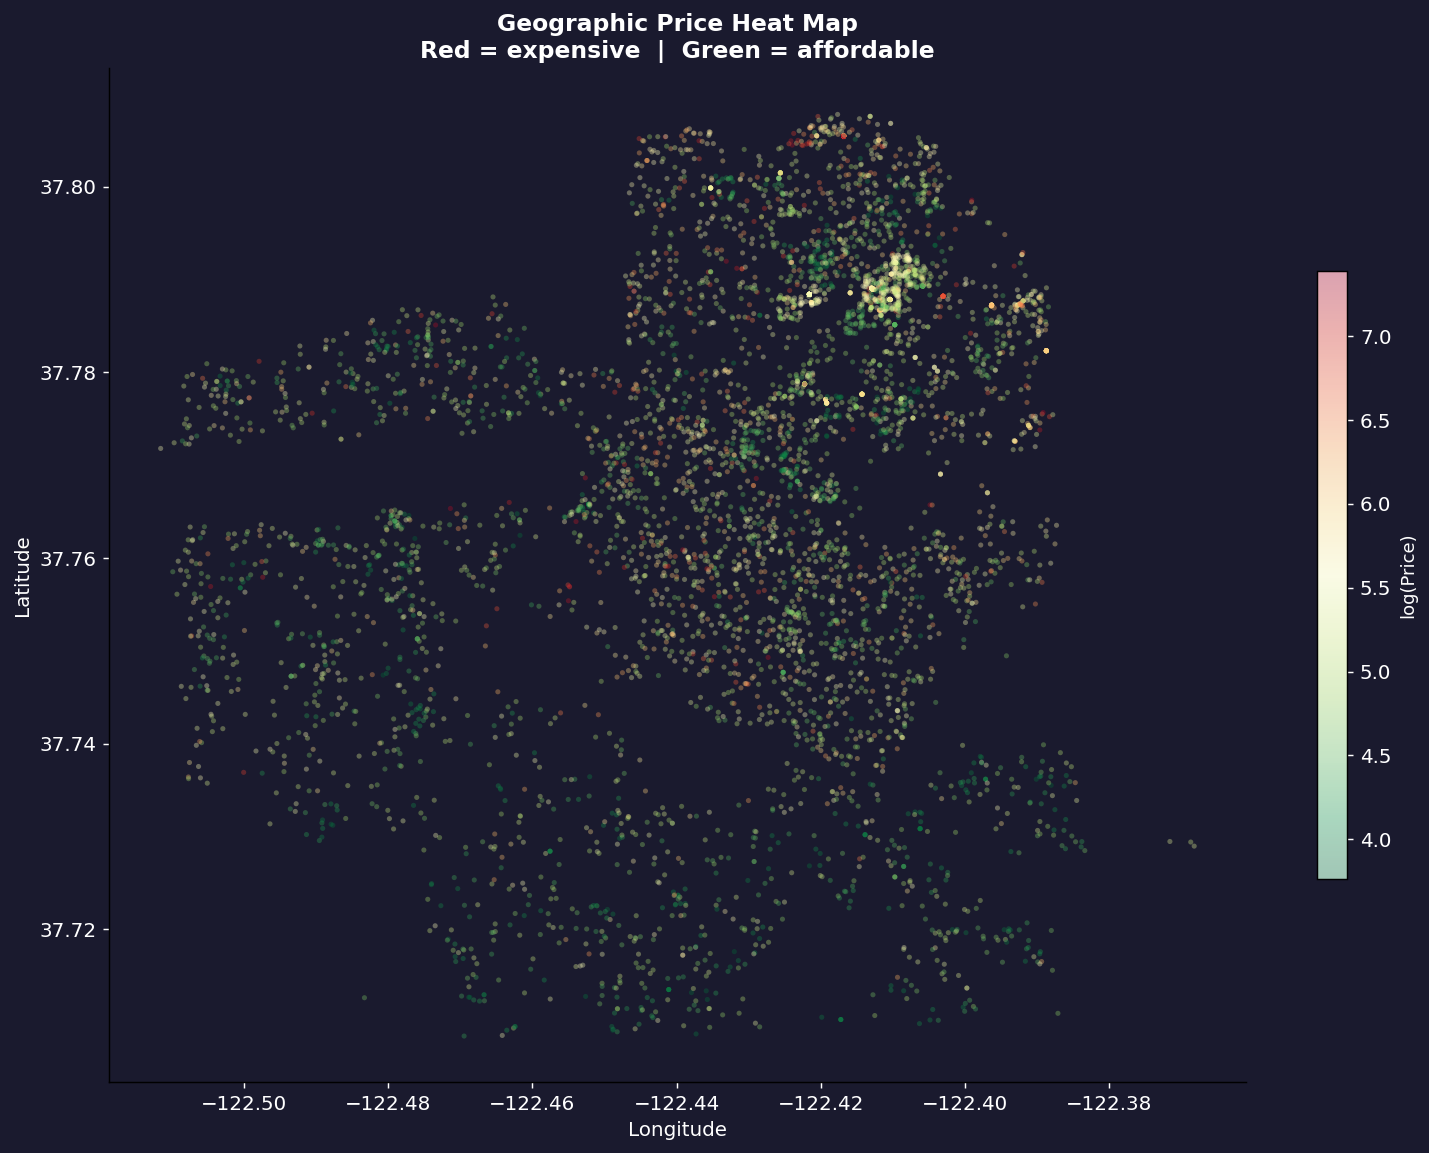

In [29]:
if "latitude" in df_top.columns and "longitude" in df_top.columns:
    fig, ax = plt.subplots(figsize=(12, 9))
    geo = df_top[["latitude", "longitude", "price"]].dropna()

    sc = ax.scatter(
        geo["longitude"], geo["latitude"],
        c=np.log1p(geo["price"]), cmap="RdYlGn_r",
        alpha=0.35, s=8, linewidths=0
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label("log(Price)", fontsize=10, color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    ax.set_xlabel("Longitude", color="white")
    ax.set_ylabel("Latitude", color="white")
    ax.set_title(
        "Geographic Price Heat Map\nRed = expensive  |  Green = affordable",
        fontsize=13, fontweight="bold", color="white"
    )
    ax.set_facecolor("#1a1a2e")
    fig.patch.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    plt.tight_layout()
    plt.show()


## Section 7 — Findings & Takeaways

### Key Takeaways

| Question | Answer |
|---|---|
| How are prices distributed? | Most listings are \\$80–\\$250/night, with a few expensive outliers |
| Which neighbourhoods cost most? | North Beach, Financil District, Downtown/ Civic Center tend to be the priciest |
| Does room type matter? | Yes — entire homes cost significantly more than private/shared rooms |
| Does property size matter? | Yes — capacity, bedrooms, and bathrooms are the strongest predictors |
| Do reviews predict price? | Weakly — ratings don't strongly determine what hosts charge |
| Is it location or property? | **Both** — but property size is a stronger day-to-day driver; neighbourhood adds a "prestige premium" on top |

---

### Practical Takeaways

**If you're a guest looking for value:**
- Look at neighbourhoods that fall *below* the trend line — you'll get more space for your money
- High location ratings don't always mean high prices

**If you're a new host:**
- Investing in more amenities and maximising capacity has a clear price benefit
- Your neighbourhood sets a "ceiling" — but the property itself determines where within that range you sit

---